<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/air_and_water_cooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air and water cooling with NeqSim

This tutorial connects a compositional NeqSim gas cooler to preliminary air-cooler and cooling-water utility design. It calculates the process duty from rigorous inlet and outlet enthalpies, sizes utility flow and conductance from engineering balances, compares fan and pump power, and tests operating sensitivities. The inputs are synthetic and intended for education—not equipment certification.

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "neqsim==3.16.0",
        ]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import clearProcess, cooler, runProcess, stream
from neqsim.thermo import TPflash, fluid

neqsim_version = importlib.metadata.version("neqsim")
print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {sys.version.split()[0]}")

NeqSim version: 3.16.0
Python version: 3.12.13


## Audience, prerequisites, and learning objectives

**Audience:** process, mechanical, energy, and production engineers; senior students; and NeqSim users learning utility-system integration. **Prerequisites:** steady-flow energy balances, heat capacity, absolute pressure, phase equilibrium, and basic Python.

After completing the notebook you can:

1. create and flash a realistic compressor-discharge gas;
2. construct a named NeqSim stream and process-side cooler;
3. reconcile cooler duty with an independent enthalpy-rate balance;
4. calculate air and cooling-water flow rates, LMTD, UA, indicative area, and auxiliary power;
5. interpret outlet-temperature, ambient, utility-rise, and pressure-drop sensitivities;
6. identify assumptions that require vendor or detailed exchanger verification.

In [2]:
process_case = {
    "inlet_pressure_bara": 70.0,
    "inlet_temperature_C": 90.0,
    "outlet_temperature_C": 35.0,
    "process_pressure_drop_bar": 0.5,
    "process_mass_flow_kg_per_h": 50_000.0,
}

air_case = {
    "inlet_temperature_C": 25.0,
    "outlet_temperature_C": 40.0,
    "air_side_pressure_drop_Pa": 250.0,
    "fan_efficiency": 0.65,
    "LMTD_correction_factor": 0.85,
    "design_overall_U_W_per_m2K": 45.0,
}

water_case = {
    "inlet_temperature_C": 20.0,
    "outlet_temperature_C": 30.0,
    "specific_heat_J_per_kgK": 4_180.0,
    "water_side_pressure_drop_Pa": 200_000.0,
    "pump_efficiency": 0.75,
    "LMTD_correction_factor": 1.0,
    "design_overall_U_W_per_m2K": 300.0,
}

gas_composition_mol_percent = {
    "nitrogen": 1.0,
    "CO2": 2.0,
    "methane": 88.0,
    "ethane": 6.0,
    "propane": 2.0,
    "n-butane": 1.0,
}

composition_total = sum(gas_composition_mol_percent.values())
assert abs(composition_total - 100.0) < 1.0e-12

pd.Series(process_case, name="SI value").to_frame()

,SI value
inlet_pressure_bara,70.0
inlet_temperature_C,90.0
outlet_temperature_C,35.0
process_pressure_drop_bar,0.5
process_mass_flow_kg_per_h,50000.0


## Process basis and stated engineering assumptions

The synthetic case represents a high-pressure natural-gas stream downstream of compression. It is cooled from 90 °C to 35 °C at 50,000 kg/h, with a stated 0.5 bar process-side loss. All pressures are absolute (`bara`) except explicitly labelled pressure differences.

The utility assumptions are deliberately visible rather than hidden “typical values.” Air warms from 25 to 40 °C; cooling water warms from 20 to 30 °C. Indicative air- and water-side pressure drops, efficiencies, correction factors, and overall heat-transfer coefficients are screening inputs. Vendor design must replace them with site weather, fouling, materials, geometry, noise, vibration, motor, water-quality, and hydraulic data.

In [3]:
def create_process_gas(
    pressure_bara=process_case["inlet_pressure_bara"],
    temperature_C=process_case["inlet_temperature_C"],
    mass_flow_kg_per_h=process_case["process_mass_flow_kg_per_h"],
):
    gas = fluid("srk")

    for component_name, mole_percent in gas_composition_mol_percent.items():
        gas.addComponent(component_name, mole_percent)

    gas.setMixingRule("classic")
    gas.setMultiPhaseCheck(True)
    gas.setPressure(pressure_bara, "bara")
    gas.setTemperature(temperature_C, "C")
    gas.setTotalFlowRate(mass_flow_kg_per_h, "kg/hr")
    TPflash(gas)
    gas.initProperties()
    return gas


hot_gas = create_process_gas()
print(f"Inlet phases: {hot_gas.getNumberOfPhases()}")
print(f"Inlet density: {hot_gas.getDensity('kg/m3'):.3f} kg/m3")
print(f"Inlet specific enthalpy: {hot_gas.getEnthalpy('J/kg'):.1f} J/kg")

Inlet phases: 1
Inlet density: 45.624 kg/m3
Inlet specific enthalpy: 137910.8 J/kg


## Thermodynamic representation and model choice

NeqSim represents the gas by components, mole amounts, the Soave–Redlich–Kwong (SRK) cubic EOS, the classic mixing rule, phases, and a thermodynamic state. SRK is selected because it is widely used for natural-gas process screening. A project model should be checked against measured composition, phase behavior, enthalpy, and transport data; richer fluids may need characterized heavy fractions and tuning.

A TP flash enforces component fugacity equality between phases. `initProperties()` then initializes density, heat capacity, viscosity, enthalpy, and other properties used by process equipment. The phase check confirms whether cooling creates liquid; phase appearance would change both duty and downstream separation requirements.

In [4]:
inlet_phase = hot_gas.getPhase(0)

inlet_properties = pd.Series(
    {
        "pressure [bara]": hot_gas.getPressure("bara"),
        "temperature [degC]": hot_gas.getTemperature("C"),
        "mass flow [kg/h]": hot_gas.getFlowRate("kg/hr"),
        "density [kg/m3]": inlet_phase.getDensity("kg/m3"),
        "heat capacity [J/(kg K)]": inlet_phase.getCp("J/kgK"),
        "viscosity [Pa s]": inlet_phase.getViscosity("kg/msec"),
        "compressibility factor [-]": inlet_phase.getZ(),
        "specific enthalpy [J/kg]": hot_gas.getEnthalpy("J/kg"),
    }
)

inlet_properties.to_frame("value").round(6)

,value
pressure [bara],70.000000
temperature [degC],90.000000
mass flow [kg/h],50000.000000
density [kg/m3],45.623526
heat capacity [J/(kg K)],2562.646883
viscosity [Pa s],0.000015
compressibility factor [-],0.944749
specific enthalpy [J/kg],137910.775634


## NeqSim stream, cooler, and solver workflow

The process object chain is

`thermodynamic fluid → named inlet stream → cooler unit operation → named outlet stream`.

The cooler specifies outlet temperature and pressure loss. During `runProcess()`, NeqSim flashes the outlet state and calculates the heat duty needed to meet the specification. The outlet stream can feed a separator, compressor scrubber, pipeline, or another process model without rebuilding the fluid. NeqSim reports cooling duty with a negative sign because heat leaves the process; this notebook reports **positive heat removed** for design clarity.

In [5]:
def run_process_cooler(
    outlet_temperature_C=process_case["outlet_temperature_C"],
    pressure_drop_bar=process_case["process_pressure_drop_bar"],
):
    inlet_fluid = create_process_gas()
    clearProcess()

    inlet_stream = stream("compressor discharge gas", inlet_fluid)
    process_cooler = cooler("gas utility cooler", inlet_stream)
    process_cooler.setOutTemperature(outlet_temperature_C, "C")
    process_cooler.setPressureDrop(pressure_drop_bar)
    runProcess()

    return {
        "inlet": inlet_stream,
        "cooler": process_cooler,
        "outlet": process_cooler.getOutStream(),
    }


base_process = run_process_cooler()
base_cooler = base_process["cooler"]
base_outlet = base_process["outlet"]
heat_removed_W = -base_cooler.getDuty()

process_summary = pd.Series(
    {
        "inlet pressure [bara]": base_process["inlet"].getPressure("bara"),
        "outlet pressure [bara]": base_outlet.getPressure("bara"),
        "inlet temperature [degC]": base_process["inlet"].getTemperature("C"),
        "outlet temperature [degC]": base_outlet.getTemperature("C"),
        "heat removed [MW]": heat_removed_W / 1.0e6,
        "outlet phases [-]": base_outlet.getFluid().getNumberOfPhases(),
    }
)

process_summary.to_frame("value").round(5)

,value
inlet pressure [bara],70.00000
outlet pressure [bara],69.50000
inlet temperature [degC],90.00000
outlet temperature [degC],35.00000
heat removed [MW],1.96187
outlet phases [-],1.00000


## Energy balance and sign convention

For a steady cooler with negligible kinetic and potential-energy changes,

\[
\dot Q_{removed}=\dot m\,(h_{in}-h_{out}).
\]

The NeqSim duty should match this independent enthalpy-rate calculation. Because pressure loss is included, the enthalpy change is not approximated only by \(c_p\Delta T\); NeqSim evaluates both end states with the EOS. The material balance must also close because the cooler has no mass source or sink.

In [6]:
mass_flow_kg_per_s = (
    base_process["inlet"].getFlowRate("kg/hr") / 3_600.0
)
inlet_enthalpy_J_per_kg = base_process["inlet"].getFluid().getEnthalpy(
    "J/kg"
)
outlet_enthalpy_J_per_kg = base_outlet.getFluid().getEnthalpy("J/kg")

enthalpy_balance_duty_W = mass_flow_kg_per_s * (
    inlet_enthalpy_J_per_kg - outlet_enthalpy_J_per_kg
)
relative_energy_error = abs(
    enthalpy_balance_duty_W - heat_removed_W
) / heat_removed_W

energy_balance = pd.Series(
    {
        "NeqSim heat removed [W]": heat_removed_W,
        "enthalpy-rate heat removed [W]": enthalpy_balance_duty_W,
        "relative energy error [-]": relative_energy_error,
        "inlet mass flow [kg/h]": base_process["inlet"].getFlowRate(
            "kg/hr"
        ),
        "outlet mass flow [kg/h]": base_outlet.getFlowRate("kg/hr"),
    }
)

energy_balance.to_frame("value")

,value
NeqSim heat removed [W],1.961869e+06
enthalpy-rate heat removed [W],1.961869e+06
relative energy error [-],0.000000e+00
inlet mass flow [kg/h],5.000000e+04
outlet mass flow [kg/h],5.000000e+04


## Represent the air and water utilities

The process duty is rigorous; the utility-side models provide properties needed for preliminary sizing. Dry air is represented by nitrogen, oxygen, argon, and carbon dioxide with SRK at the mean air temperature and atmospheric pressure. Water uses CPA at the mean water temperature and 3 bara because association improves liquid-water density and phase behavior.

For cooling-water flow, the notebook uses the documented engineering approximation \(c_p=4.18\) kJ/(kg·K) over 20–30 °C. NeqSim supplies water density for volumetric flow. This separation is explicit because the utility calculation is a screening balance, not a claim that one EOS is a high-accuracy liquid-water caloric model.

In [7]:
def create_air_utility(mean_temperature_C):
    air = fluid("srk")
    air_composition_mol_percent = {
        "nitrogen": 78.08,
        "oxygen": 20.95,
        "argon": 0.93,
        "CO2": 0.04,
    }

    for component_name, mole_percent in air_composition_mol_percent.items():
        air.addComponent(component_name, mole_percent)

    air.setMixingRule("classic")
    air.setPressure(1.01325, "bara")
    air.setTemperature(mean_temperature_C, "C")
    air.setTotalFlowRate(1.0, "kg/sec")
    TPflash(air)
    air.initProperties()
    return air


def create_water_utility(mean_temperature_C):
    water = fluid("cpa")
    water.addComponent("water", 1.0)
    water.setMixingRule(10)
    water.setPressure(3.0, "bara")
    water.setTemperature(mean_temperature_C, "C")
    water.setTotalFlowRate(1.0, "kg/sec")
    TPflash(water)
    water.initProperties()
    return water


mean_air_temperature_C = 0.5 * (
    air_case["inlet_temperature_C"] + air_case["outlet_temperature_C"]
)
mean_water_temperature_C = 0.5 * (
    water_case["inlet_temperature_C"] + water_case["outlet_temperature_C"]
)

air_utility = create_air_utility(mean_air_temperature_C)
water_utility = create_water_utility(mean_water_temperature_C)

## Property checks against physical limits

At low pressure, the air density should approach the ideal-gas result \(\rho=PM/(RT)\), and its heat capacity should be near 1.0 kJ/(kg·K). Liquid-water density near room temperature should be close to 1,000 kg/m³. These are independent physical screens rather than tuned benchmarks.

The checks also catch unit mistakes: Pa versus bar, kelvin versus degrees Celsius, kg/s versus kg/h, and dynamic-viscosity units are frequent sources of utility-sizing errors.

In [8]:
air_phase = air_utility.getPhase("gas")
water_phase = water_utility.getPhase(0)

air_heat_capacity_J_per_kgK = air_phase.getCp("J/kgK")
air_density_kg_per_m3 = air_phase.getDensity("kg/m3")
water_density_kg_per_m3 = water_phase.getDensity("kg/m3")

universal_gas_constant_J_per_molK = 8.314462618
air_pressure_Pa = 101_325.0
air_temperature_K = mean_air_temperature_C + 273.15
air_molar_mass_kg_per_mol = air_utility.getMolarMass()
ideal_air_density_kg_per_m3 = (
    air_pressure_Pa
    * air_molar_mass_kg_per_mol
    / (universal_gas_constant_J_per_molK * air_temperature_K)
)

utility_properties = pd.DataFrame(
    {
        "quantity": [
            "NeqSim air heat capacity",
            "NeqSim air density",
            "ideal-gas air density",
            "NeqSim liquid-water density",
        ],
        "value": [
            air_heat_capacity_J_per_kgK,
            air_density_kg_per_m3,
            ideal_air_density_kg_per_m3,
            water_density_kg_per_m3,
        ],
        "unit": ["J/(kg K)", "kg/m3", "kg/m3", "kg/m3"],
    }
)

utility_properties.round(4)

,quantity,value,unit
0,NeqSim air heat capacity,1006.4564,J/(kg K)
1,NeqSim air density,1.1551,kg/m3
2,ideal-gas air density,1.1549,kg/m3
3,NeqSim liquid-water density,995.0713,kg/m3


## LMTD, conductance, and area equations

For countercurrent terminal differences,

\[
\Delta T_1=T_{h,in}-T_{c,out},\qquad
\Delta T_2=T_{h,out}-T_{c,in},
\]

\[
\Delta T_{lm}=\frac{\Delta T_1-\Delta T_2}
{\ln(\Delta T_1/\Delta T_2)},\qquad
UA=\frac{\dot Q}{F\Delta T_{lm}},\qquad
A=\frac{UA}{U_{design}}.
\]

Every terminal difference must be positive. The correction factor \(F\) accounts approximately for crossflow or multipass geometry. Area depends strongly on the stated overall \(U\), fouling basis, and whether air-cooler area is bare-tube or extended surface; therefore it is indicative only.

In [9]:
def calculate_lmtd(
    hot_inlet_C,
    hot_outlet_C,
    cold_inlet_C,
    cold_outlet_C,
):
    hot_end_difference_K = hot_inlet_C - cold_outlet_C
    cold_end_difference_K = hot_outlet_C - cold_inlet_C

    if hot_end_difference_K <= 0.0 or cold_end_difference_K <= 0.0:
        raise ValueError("Temperature cross makes the specified cooler infeasible")

    if abs(hot_end_difference_K - cold_end_difference_K) < 1.0e-12:
        return hot_end_difference_K

    temperature_ratio = hot_end_difference_K / cold_end_difference_K
    return (
        hot_end_difference_K - cold_end_difference_K
    ) / np.log(temperature_ratio)


def calculate_conductance_and_area(
    duty_W,
    lmtd_K,
    correction_factor,
    overall_U_W_per_m2K,
):
    conductance_W_per_K = duty_W / (correction_factor * lmtd_K)
    area_m2 = conductance_W_per_K / overall_U_W_per_m2K
    return conductance_W_per_K, area_m2

## Air-cooler screening design

Air mass flow follows \(\dot m_a=\dot Q/(c_{p,a}\Delta T_a)\). Actual volumetric flow uses NeqSim density at the mean air temperature. Indicative fan shaft power is

\[
W_{fan}=\frac{\Delta P_a\dot V_a}{\eta_{fan}}.
\]

The assumed 250 Pa air-side loss and 65% efficiency are transparent scenario inputs, not vendor guarantees. Air-cooler design must additionally address seasonal dry-bulb temperature, recirculation, bundle arrangement, fin fouling, fan curves, motor margin, noise, vibration, minimum turndown, and natural-draft behavior.

In [10]:
air_temperature_rise_K = (
    air_case["outlet_temperature_C"] - air_case["inlet_temperature_C"]
)
air_mass_flow_kg_per_s = heat_removed_W / (
    air_heat_capacity_J_per_kgK * air_temperature_rise_K
)
air_volume_flow_m3_per_s = (
    air_mass_flow_kg_per_s / air_density_kg_per_m3
)
fan_power_W = (
    air_case["air_side_pressure_drop_Pa"]
    * air_volume_flow_m3_per_s
    / air_case["fan_efficiency"]
)

air_lmtd_K = calculate_lmtd(
    process_case["inlet_temperature_C"],
    process_case["outlet_temperature_C"],
    air_case["inlet_temperature_C"],
    air_case["outlet_temperature_C"],
)
air_conductance_W_per_K, air_area_m2 = calculate_conductance_and_area(
    heat_removed_W,
    air_lmtd_K,
    air_case["LMTD_correction_factor"],
    air_case["design_overall_U_W_per_m2K"],
)

air_cooler_summary = pd.Series(
    {
        "air mass flow [kg/s]": air_mass_flow_kg_per_s,
        "air actual volume flow [m3/s]": air_volume_flow_m3_per_s,
        "LMTD [K]": air_lmtd_K,
        "required UA [kW/K]": air_conductance_W_per_K / 1.0e3,
        "indicative extended area [m2]": air_area_m2,
        "fan shaft power [kW]": fan_power_W / 1.0e3,
    }
)

air_cooler_summary.to_frame("value").round(3)

,value
air mass flow [kg/s],129.952
air actual volume flow [m3/s],112.508
LMTD [K],24.853
required UA [kW/K],92.868
indicative extended area [m2],2063.730
fan shaft power [kW],43.272


## Cooling-water screening design

Cooling-water mass flow is \(\dot m_w=\dot Q/(c_{p,w}\Delta T_w)\). Volumetric flow uses NeqSim liquid density, and indicative pump shaft power is

\[
W_{pump}=\frac{\Delta P_w\dot V_w}{\eta_{pump}}.
\]

The 200 kPa exchanger/circuit loss excludes static head recovery assumptions and must be replaced by a complete hydraulic system curve. Detailed water-cooler design also requires fouling resistance, scaling/corrosion limits, velocity and erosion checks, tube-side pressure design, cooling-tower performance, water treatment, discharge temperature constraints, and exchanger mechanical design.

In [11]:
water_temperature_rise_K = (
    water_case["outlet_temperature_C"]
    - water_case["inlet_temperature_C"]
)
water_mass_flow_kg_per_s = heat_removed_W / (
    water_case["specific_heat_J_per_kgK"] * water_temperature_rise_K
)
water_volume_flow_m3_per_s = (
    water_mass_flow_kg_per_s / water_density_kg_per_m3
)
pump_power_W = (
    water_case["water_side_pressure_drop_Pa"]
    * water_volume_flow_m3_per_s
    / water_case["pump_efficiency"]
)

water_lmtd_K = calculate_lmtd(
    process_case["inlet_temperature_C"],
    process_case["outlet_temperature_C"],
    water_case["inlet_temperature_C"],
    water_case["outlet_temperature_C"],
)
water_conductance_W_per_K, water_area_m2 = (
    calculate_conductance_and_area(
        heat_removed_W,
        water_lmtd_K,
        water_case["LMTD_correction_factor"],
        water_case["design_overall_U_W_per_m2K"],
    )
)

water_cooler_summary = pd.Series(
    {
        "water mass flow [kg/s]": water_mass_flow_kg_per_s,
        "water volume flow [m3/h]": water_volume_flow_m3_per_s * 3_600.0,
        "LMTD [K]": water_lmtd_K,
        "required UA [kW/K]": water_conductance_W_per_K / 1.0e3,
        "indicative heat-transfer area [m2]": water_area_m2,
        "pump shaft power [kW]": pump_power_W / 1.0e3,
    }
)

water_cooler_summary.to_frame("value").round(3)

,value
water mass flow [kg/s],46.935
water volume flow [m3/h],169.802
LMTD [K],32.461
required UA [kW/K],60.438
indicative heat-transfer area [m2],201.461
pump shaft power [kW],12.578


## Compare the utility concepts

Both concepts remove the same NeqSim process duty and reach the same gas outlet specification. Their utility flows, UA values, indicative areas, and auxiliary powers differ because heat capacity, density, terminal temperatures, overall heat-transfer coefficient, pressure loss, and efficiency differ.

The table is a concept-screening comparison, not a universal ranking. Air cooling avoids cooling-water consumption and treatment but is weather-sensitive and often needs large finned area and fan power. Water cooling is compact and less sensitive to dry-bulb temperature but requires water supply, treatment, pumping, heat rejection, and discharge management.

In [12]:
comparison_table = pd.DataFrame(
    {
        "concept": ["air cooler", "cooling-water exchanger"],
        "process duty [MW]": [
            heat_removed_W / 1.0e6,
            heat_removed_W / 1.0e6,
        ],
        "utility mass flow [kg/s]": [
            air_mass_flow_kg_per_s,
            water_mass_flow_kg_per_s,
        ],
        "utility volume flow [m3/s]": [
            air_volume_flow_m3_per_s,
            water_volume_flow_m3_per_s,
        ],
        "LMTD [K]": [air_lmtd_K, water_lmtd_K],
        "required UA [kW/K]": [
            air_conductance_W_per_K / 1.0e3,
            water_conductance_W_per_K / 1.0e3,
        ],
        "indicative area [m2]": [air_area_m2, water_area_m2],
        "auxiliary shaft power [kW]": [
            fan_power_W / 1.0e3,
            pump_power_W / 1.0e3,
        ],
    }
)

comparison_table.set_index("concept").round(4)

,process duty [MW],utility mass flow [kg/s],utility volume flow [m3/s],LMTD [K],required UA [kW/K],indicative area [m2],auxiliary shaft power [kW]
concept,,,,,,,
air cooler,1.9619,129.9522,112.5075,24.8534,92.8678,2063.7295,43.2721
cooling-water exchanger,1.9619,46.9347,0.0472,32.4606,60.4384,201.4613,12.5779


## Process outlet-temperature sensitivity

Lower gas outlet temperature increases the rigorous NeqSim duty and may eventually cause hydrocarbon or water condensation. Each scenario rebuilds and solves the cooler independently, preventing hidden state. The phase count is retained as an explicit check.

The selected dry gas remains single phase over 30–50 °C. A richer gas could require a cooler followed by a separator; in that case, liquid dropout and component routing should be included in both process and utility design.

In [13]:
outlet_temperature_rows = []

for outlet_temperature_C in [30.0, 35.0, 40.0, 45.0, 50.0]:
    scenario = run_process_cooler(
        outlet_temperature_C=outlet_temperature_C,
    )
    scenario_heat_removed_W = -scenario["cooler"].getDuty()
    scenario_phase_count = scenario["outlet"].getFluid().getNumberOfPhases()

    outlet_temperature_rows.append(
        {
            "gas outlet temperature [degC]": outlet_temperature_C,
            "heat removed [MW]": scenario_heat_removed_W / 1.0e6,
            "gas outlet pressure [bara]": scenario["outlet"].getPressure(
                "bara"
            ),
            "outlet phases [-]": scenario_phase_count,
        }
    )

outlet_temperature_table = pd.DataFrame(outlet_temperature_rows)
outlet_temperature_table.round(5)

,gas outlet temperature [degC],heat removed [MW],gas outlet pressure [bara],outlet phases [-]
0,30.0,2.14527,69.5,1
1,35.0,1.96187,69.5,1
2,40.0,1.77989,69.5,1
3,45.0,1.59908,69.5,1
4,50.0,1.41921,69.5,1


## Ambient-air sensitivity and approach-temperature limit

For a fixed 35 °C gas outlet and a 15 K air rise, hotter ambient air reduces both terminal temperature differences and LMTD. Required UA therefore increases. The cold-end approach \(T_{gas,out}-T_{air,in}\) must remain positive; it becomes a hard feasibility constraint before ambient reaches the gas target.

Real design uses a specified summer design dry-bulb temperature, solar and recirculation allowances, and an operating strategy for colder weather. The sweep covers 5–30 °C and does not extrapolate through a temperature cross.

In [14]:
ambient_rows = []

for air_inlet_temperature_C in [5.0, 10.0, 15.0, 20.0, 25.0, 30.0]:
    air_outlet_temperature_C = air_inlet_temperature_C + 15.0
    scenario_lmtd_K = calculate_lmtd(
        process_case["inlet_temperature_C"],
        process_case["outlet_temperature_C"],
        air_inlet_temperature_C,
        air_outlet_temperature_C,
    )
    scenario_conductance_W_per_K, scenario_area_m2 = (
        calculate_conductance_and_area(
            heat_removed_W,
            scenario_lmtd_K,
            air_case["LMTD_correction_factor"],
            air_case["design_overall_U_W_per_m2K"],
        )
    )

    ambient_rows.append(
        {
            "air inlet temperature [degC]": air_inlet_temperature_C,
            "cold-end approach [K]": (
                process_case["outlet_temperature_C"]
                - air_inlet_temperature_C
            ),
            "LMTD [K]": scenario_lmtd_K,
            "required UA [kW/K]": scenario_conductance_W_per_K / 1.0e3,
            "indicative area [m2]": scenario_area_m2,
        }
    )

ambient_table = pd.DataFrame(ambient_rows)
ambient_table.round(4)

,air inlet temperature [degC],cold-end approach [K],LMTD [K],required UA [kW/K],indicative area [m2]
0,5.0,30.0,47.2089,48.8908,1086.4623
1,10.0,25.0,41.8624,55.1349,1225.2210
2,15.0,20.0,36.4096,63.3922,1408.7146
3,20.0,15.0,30.7862,74.9713,1666.0280
4,25.0,10.0,24.8534,92.8678,2063.7295
5,30.0,5.0,18.2048,126.7843,2817.4291


## Utility temperature-rise sensitivity

At fixed duty, a larger allowed utility temperature rise reduces mass flow. This can lower fan or pump flow but changes LMTD, heat-transfer area, outlet constraints, and equipment temperatures. The sweep recalculates utility flow and terminal differences for every scenario.

Air is tested over 10–25 K rise at 25 °C inlet; water is tested over 5–15 K rise at 20 °C inlet. All cases retain positive terminal differences. Water outlet-temperature constraints may be set by cooling towers, scaling, biological growth, discharge permits, or downstream users.

In [15]:
air_rise_rows = []

for air_temperature_rise_K in [10.0, 15.0, 20.0, 25.0]:
    scenario_air_outlet_C = (
        air_case["inlet_temperature_C"] + air_temperature_rise_K
    )
    scenario_air_flow_kg_per_s = heat_removed_W / (
        air_heat_capacity_J_per_kgK * air_temperature_rise_K
    )
    scenario_air_lmtd_K = calculate_lmtd(
        process_case["inlet_temperature_C"],
        process_case["outlet_temperature_C"],
        air_case["inlet_temperature_C"],
        scenario_air_outlet_C,
    )

    air_rise_rows.append(
        {
            "utility temperature rise [K]": air_temperature_rise_K,
            "utility mass flow [kg/s]": scenario_air_flow_kg_per_s,
            "LMTD [K]": scenario_air_lmtd_K,
        }
    )

water_rise_rows = []

for water_temperature_rise_K in [5.0, 10.0, 15.0]:
    scenario_water_outlet_C = (
        water_case["inlet_temperature_C"] + water_temperature_rise_K
    )
    scenario_water_flow_kg_per_s = heat_removed_W / (
        water_case["specific_heat_J_per_kgK"]
        * water_temperature_rise_K
    )
    scenario_water_lmtd_K = calculate_lmtd(
        process_case["inlet_temperature_C"],
        process_case["outlet_temperature_C"],
        water_case["inlet_temperature_C"],
        scenario_water_outlet_C,
    )

    water_rise_rows.append(
        {
            "utility temperature rise [K]": water_temperature_rise_K,
            "utility mass flow [kg/s]": scenario_water_flow_kg_per_s,
            "LMTD [K]": scenario_water_lmtd_K,
        }
    )

air_rise_table = pd.DataFrame(air_rise_rows)
water_rise_table = pd.DataFrame(water_rise_rows)

display(air_rise_table.round(4))
display(water_rise_table.round(4))

   utility temperature rise [K]  utility mass flow [kg/s]  LMTD [K]
0                          10.0                  194.9283   26.3969
1                          15.0                  129.9522   24.8534
2                          20.0                   97.4642   23.2701
3                          25.0                   77.9713   21.6404
   utility temperature rise [K]  utility mass flow [kg/s]  LMTD [K]
0                           5.0                   93.8693   34.0986
1                          10.0                   46.9347   32.4606
2                          15.0                   31.2898   30.7862


## Process-side pressure-drop sensitivity

Cooler pressure loss consumes compression margin and slightly changes the enthalpy duty required to reach a fixed temperature. NeqSim includes that thermodynamic coupling by flashing each outlet at its specified pressure and temperature.

The sweep uses 0–2 bar loss. Detailed design must calculate nozzle, header, tube or finned-tube, bend, and fitting losses at clean and fouled conditions. The allowable loss should be allocated from the full process hydraulic and compressor-operability study—not selected only to reduce exchanger size.

In [16]:
pressure_drop_rows = []

for pressure_drop_bar in [0.0, 0.5, 1.0, 2.0]:
    scenario = run_process_cooler(
        pressure_drop_bar=pressure_drop_bar,
    )
    pressure_drop_rows.append(
        {
            "specified pressure drop [bar]": pressure_drop_bar,
            "outlet pressure [bara]": scenario["outlet"].getPressure(
                "bara"
            ),
            "heat removed [MW]": -scenario["cooler"].getDuty() / 1.0e6,
            "outlet temperature [degC]": scenario["outlet"].getTemperature(
                "C"
            ),
        }
    )

pressure_drop_table = pd.DataFrame(pressure_drop_rows)
pressure_drop_table.round(6)

,specified pressure drop [bar],outlet pressure [bara],heat removed [MW],outlet temperature [degC]
0,0.0,70.0,1.969380,35.0
1,0.5,69.5,1.961869,35.0
2,1.0,69.0,1.954354,35.0
3,2.0,68.0,1.939313,35.0


## Visual engineering interpretation

The plots show four distinct design relationships: colder gas requires more duty; hotter ambient requires more UA; larger utility temperature rise reduces flow; and process pressure loss changes both outlet pressure and duty. Smooth curves and correct limiting trends are part of the validation evidence.

Plots do not remove the need to inspect tables and units. In particular, the air and water flow curves use the same mass-flow axis but represent utilities with very different densities and hydraulic implications.

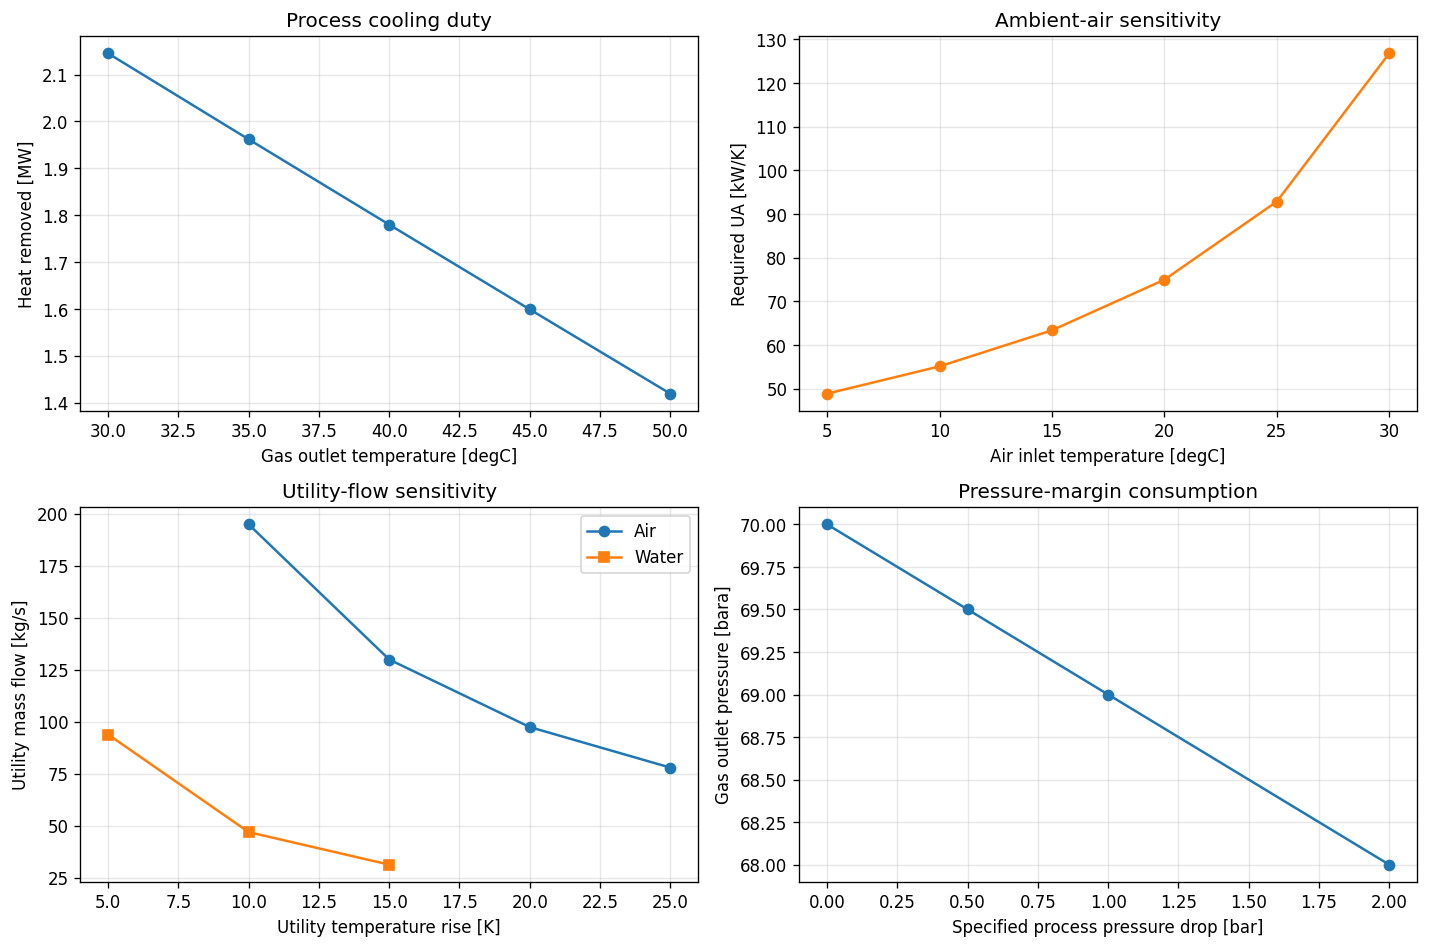

In [17]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(
    outlet_temperature_table["gas outlet temperature [degC]"],
    outlet_temperature_table["heat removed [MW]"],
    marker="o",
)
axes[0, 0].set(
    xlabel="Gas outlet temperature [degC]",
    ylabel="Heat removed [MW]",
    title="Process cooling duty",
)

axes[0, 1].plot(
    ambient_table["air inlet temperature [degC]"],
    ambient_table["required UA [kW/K]"],
    marker="o",
    color="tab:orange",
)
axes[0, 1].set(
    xlabel="Air inlet temperature [degC]",
    ylabel="Required UA [kW/K]",
    title="Ambient-air sensitivity",
)

axes[1, 0].plot(
    air_rise_table["utility temperature rise [K]"],
    air_rise_table["utility mass flow [kg/s]"],
    marker="o",
    label="Air",
)
axes[1, 0].plot(
    water_rise_table["utility temperature rise [K]"],
    water_rise_table["utility mass flow [kg/s]"],
    marker="s",
    label="Water",
)
axes[1, 0].set(
    xlabel="Utility temperature rise [K]",
    ylabel="Utility mass flow [kg/s]",
    title="Utility-flow sensitivity",
)
axes[1, 0].legend()

axes[1, 1].plot(
    pressure_drop_table["specified pressure drop [bar]"],
    pressure_drop_table["outlet pressure [bara]"],
    marker="o",
)
axes[1, 1].set(
    xlabel="Specified process pressure drop [bar]",
    ylabel="Gas outlet pressure [bara]",
    title="Pressure-margin consumption",
)

for axis in axes.flat:
    axis.grid(alpha=0.3)

figure.tight_layout()
plt.show()

## Verification, troubleshooting, summary, and references

**Verification.** The executable checks below provide conservation/thermodynamic consistency, an ideal-gas density comparison, physical property bounds, exact pressure accounting, repeatability, and expected sensitivity trends. This is stronger than “the notebook runs,” but it is not a vendor thermal rating or experimental benchmark.

**Troubleshooting.** If the outlet becomes multiphase, add a separator and include latent heat and liquid routing. If LMTD fails, the terminal temperatures imply a cross; relax the target or change the utility. If duty sign is confusing, remember NeqSim reports cooling as negative process heat. If air or water flow is implausible, check kg/h versus kg/s, Pa versus bar, and kelvin versus degrees Celsius. If a scenario does not converge, approach it in smaller temperature or pressure steps.

**Summary.** NeqSim supplies the compositional fluid, flashes, streams, process cooler, enthalpies, phase checks, density, and rigorous process duty. Transparent engineering equations translate that duty into air- and water-utility flow, LMTD, UA, indicative area, and auxiliary power. The resulting outlet stream remains available for a larger process simulation.

**Further exercises.** Add a compressor upstream and connect its discharge stream directly. Use a richer gas that condenses and add a downstream scrubber. Replace fixed overall coefficients with film, wall, fouling, and fin resistances. Add seasonal weather cases and fan staging. Close a cooling-water loop with pump and cooling tower. Compare lifecycle power, water use, emissions, footprint, and cost.

**Authoritative references.** [NeqSim documentation](https://equinor.github.io/neqsimhome/). ISO 13706/API Standard 661, *Air-cooled heat exchangers for general refinery service*. TEMA, *Standards of the Tubular Exchanger Manufacturers Association*. IAPWS, *Revised Release on the IAPWS Industrial Formulation 1997 for the Thermodynamic Properties of Water and Steam*. Incropera et al., *Fundamentals of Heat and Mass Transfer*.

In [18]:
repeat_process = run_process_cooler()
repeat_heat_removed_W = -repeat_process["cooler"].getDuty()

air_density_relative_error = abs(
    air_density_kg_per_m3 - ideal_air_density_kg_per_m3
) / ideal_air_density_kg_per_m3

checks = {
    "gas composition closes": abs(composition_total - 100.0) < 1.0e-12,
    "inlet gas is single phase": hot_gas.getNumberOfPhases() == 1,
    "outlet gas is single phase": (
        base_outlet.getFluid().getNumberOfPhases() == 1
    ),
    "cooler mass balance closes": abs(
        base_process["inlet"].getFlowRate("kg/hr")
        - base_outlet.getFlowRate("kg/hr")
    )
    < 1.0e-8,
    "cooler energy balance closes": relative_energy_error < 1.0e-12,
    "heat removed is positive": heat_removed_W > 0.0,
    "specified process pressure drop is met": abs(
        base_outlet.getPressure("bara")
        - (
            process_case["inlet_pressure_bara"]
            - process_case["process_pressure_drop_bar"]
        )
    )
    < 1.0e-10,
    "air heat capacity is physically plausible": (
        950.0 < air_heat_capacity_J_per_kgK < 1_100.0
    ),
    "air density approaches ideal gas": air_density_relative_error < 0.02,
    "water density is physically plausible": (
        980.0 < water_density_kg_per_m3 < 1_010.0
    ),
    "air terminal differences are positive": air_lmtd_K > 0.0,
    "water terminal differences are positive": water_lmtd_K > 0.0,
    "air utility flow and fan power are positive": (
        air_mass_flow_kg_per_s > 0.0 and fan_power_W > 0.0
    ),
    "water utility flow and pump power are positive": (
        water_mass_flow_kg_per_s > 0.0 and pump_power_W > 0.0
    ),
    "warmer gas target lowers duty": np.all(
        np.diff(outlet_temperature_table["heat removed [MW]"]) < 0.0
    ),
    "outlet scenarios remain single phase": (
        outlet_temperature_table["outlet phases [-]"].eq(1).all()
    ),
    "hotter ambient raises required UA": np.all(
        np.diff(ambient_table["required UA [kW/K]"]) > 0.0
    ),
    "larger air temperature rise lowers air flow": np.all(
        np.diff(air_rise_table["utility mass flow [kg/s]"]) < 0.0
    ),
    "larger water temperature rise lowers water flow": np.all(
        np.diff(water_rise_table["utility mass flow [kg/s]"]) < 0.0
    ),
    "pressure sweep matches specified outlet pressures": np.allclose(
        pressure_drop_table["outlet pressure [bara]"],
        process_case["inlet_pressure_bara"]
        - pressure_drop_table["specified pressure drop [bar]"],
        rtol=0.0,
        atol=1.0e-10,
    ),
    "base process is repeatable": abs(
        repeat_heat_removed_W - heat_removed_W
    )
    < 1.0e-9,
}

assert all(checks.values()), {
    check_name: passed
    for check_name, passed in checks.items()
    if not passed
}

result_record = {
    "neqsim_version": neqsim_version,
    "fluid_model": "SRK EOS with classic mixing rule",
    "heat_removed_MW": round(heat_removed_W / 1.0e6, 5),
    "air_flow_kg_per_s": round(air_mass_flow_kg_per_s, 3),
    "water_flow_kg_per_s": round(water_mass_flow_kg_per_s, 3),
    "air_required_UA_kW_per_K": round(
        air_conductance_W_per_K / 1.0e3,
        3,
    ),
    "water_required_UA_kW_per_K": round(
        water_conductance_W_per_K / 1.0e3,
        3,
    ),
    "validated_checks": len(checks),
}

display(pd.Series(checks, name="passed").to_frame())
pd.Series(result_record, name="validated result").to_frame()

                                                   passed
gas composition closes                               True
inlet gas is single phase                            True
outlet gas is single phase                           True
cooler mass balance closes                           True
cooler energy balance closes                         True
heat removed is positive                             True
specified process pressure drop is met               True
air heat capacity is physically plausible            True
air density approaches ideal gas                     True
water density is physically plausible                True
air terminal differences are positive                True
water terminal differences are positive              True
air utility flow and fan power are positive          True
water utility flow and pump power are positive       True
warmer gas target lowers duty                        True
outlet scenarios remain single phase                 True
hotter ambient

,validated result
neqsim_version,3.16.0
fluid_model,SRK EOS with classic mixing rule
heat_removed_MW,1.96187
air_flow_kg_per_s,129.952
water_flow_kg_per_s,46.935
air_required_UA_kW_per_K,92.868
water_required_UA_kW_per_K,60.438
validated_checks,21
